### 주요 문제 구간 선정 분석

##### 1. 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from matplotlib import font_manager
from pathlib import Path

base_path = Path(
    r"C:\DA15_Part4\sns-project\team4-final-project\data\processed"
)

# 가입
df_user2 = pd.read_csv(
    base_path / "accounts_user_preprocessed_2.csv",
    usecols=["id"]
)

# 친구 관계
df_friend2 = pd.read_csv(
    base_path / "accounts_friendrequest_preprocessed_2.csv",
    usecols=["status", "send_user_id", "receive_user_id"]
)

# 투표 수신
df_uqr2 = pd.read_csv(
    base_path / "accounts_userquestionrecord_preprocessed_2.csv",
    usecols=["chosen_user_id", "created_at"],
    parse_dates=["created_at"]
)

# 재화 소모
df_point2 = pd.read_csv(
    base_path / "accounts_pointhistory_preprocessed_2.csv",
    usecols=["user_id", "created_at"],
    parse_dates=["created_at"]
)

# 결제
df_payment2 = pd.read_csv(
    base_path / "accounts_paymenthistory_preprocessed_2.csv",
    usecols=["user_id", "created_at"],
    parse_dates=["created_at"]
)

# 여섯 번째 파일
df_qpiece2 = pd.read_csv(
    base_path / "polls_questionpiece_preprocessed_2.csv",
    usecols=["id", "is_voted"]
)

##### 2. 시각화 환경 설정

In [2]:
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

#### 1차 행동 루프 계산

##### 3. Step 1 — 가입/진입 사용자

In [3]:
all_users = set(
    pd.to_numeric(df_user2["id"], errors="coerce")
    .dropna()
    .astype("int64")
    .unique()
)

print(f"Step 1 가입/진입: {len(all_users):,}명")

Step 1 가입/진입: 677,075명


##### 4. Step 2 — 친구 관계 형성 사용자

In [4]:
df_friend_a = df_friend2[
    df_friend2["status"] == "A"
]

friend_users = set(
    pd.to_numeric(
        pd.concat([
            df_friend_a["send_user_id"],
            df_friend_a["receive_user_id"]
        ]),
        errors="coerce"
    )
    .dropna()
    .astype("int64")
    .unique()
) & all_users

stage2 = pd.DataFrame({
    "user_id": list(friend_users)
})

print(f"Step 2 친구 관계 형성: {len(friend_users):,}명")

Step 2 친구 관계 형성: 574,163명


##### 5. Step 3 — 투표 수신 사용자

In [5]:
first_vote = (
    df_uqr2
    .dropna(subset=["chosen_user_id", "created_at"])
    .groupby("chosen_user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={
        "chosen_user_id": "user_id",
        "created_at": "vote_at"
    })
)

first_vote["user_id"] = (
    first_vote["user_id"].astype("int64")
)

stage3 = stage2.merge(
    first_vote,
    on="user_id",
    how="inner"
)

vote_users = set(stage3["user_id"])

print(f"Step 3 투표 수신: {len(vote_users):,}명")

Step 3 투표 수신: 10,647명


##### 6. Step 4 — 재화 소모 사용자

In [6]:
point_spend_users = (
    df_point2[["user_id"]]
    .dropna()
    .drop_duplicates()
    .copy()
)

point_spend_users["user_id"] = (
    point_spend_users["user_id"].astype("int64")
)

stage4 = stage3.merge(
    point_spend_users,
    on="user_id",
    how="inner"
)

spend_users = set(stage4["user_id"])

print(f"Step 4 재화 소모: {len(spend_users):,}명")

Step 4 재화 소모: 3,367명


##### 7. Step 5 — 첫 결제 사용자

In [7]:
first_payment = (
    df_payment2
    .dropna(subset=["user_id", "created_at"])
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={"created_at": "first_payment_at"})
)

first_payment["user_id"] = (
    first_payment["user_id"].astype("int64")
)

stage5 = stage4.merge(
    first_payment,
    on="user_id",
    how="inner"
)

payment_users = set(stage5["user_id"])

print(f"Step 5 첫 결제: {len(payment_users):,}명")

Step 5 첫 결제: 358명


#### 2차 행동 루프 계산

##### 8. Step 6 — 첫 결제 후 다시 투표 수신

In [8]:
vote_after_payment = (
    df_uqr2[["chosen_user_id", "created_at"]]
    .dropna(subset=["chosen_user_id", "created_at"])
    .rename(columns={
        "chosen_user_id": "user_id",
        "created_at": "vote_after_payment_at"
    })
    .copy()
)

vote_after_payment["user_id"] = (
    vote_after_payment["user_id"].astype("int64")
)

stage6 = (
    stage5[["user_id", "first_payment_at"]]
    .drop_duplicates("user_id")
    .merge(
        vote_after_payment,
        on="user_id",
        how="inner"
    )
)

# 첫 결제 이후 다시 받은 투표만 인정
stage6 = stage6[
    stage6["vote_after_payment_at"]
    > stage6["first_payment_at"]
].copy()

stage6 = (
    stage6
    .sort_values("vote_after_payment_at")
    .drop_duplicates("user_id")
)

revote_users = set(stage6["user_id"])

print(f"Step 6 첫 결제 후 투표 수신: {len(revote_users):,}명")

Step 6 첫 결제 후 투표 수신: 353명


##### 9. Step 7 — 재투표 후 재화 소모

In [9]:
point_after_vote = (
    df_point2[["user_id", "created_at"]]
    .dropna(subset=["user_id", "created_at"])
    .rename(columns={
        "created_at": "spend_after_vote_at"
    })
    .copy()
)

point_after_vote["user_id"] = (
    point_after_vote["user_id"].astype("int64")
)

stage7 = stage6.merge(
    point_after_vote,
    on="user_id",
    how="inner"
)

# 다시 투표를 받은 이후의 재화 소모만 인정
stage7 = stage7[
    stage7["spend_after_vote_at"]
    > stage7["vote_after_payment_at"]
].copy()

stage7 = (
    stage7
    .sort_values("spend_after_vote_at")
    .drop_duplicates("user_id")
)

respend_users = set(stage7["user_id"])

print(f"Step 7 재투표 후 재화 소모: {len(respend_users):,}명")

Step 7 재투표 후 재화 소모: 334명


##### 10. Step 8 — 재결제 사용자

In [10]:
payment_again = (
    df_payment2[["user_id", "created_at"]]
    .dropna(subset=["user_id", "created_at"])
    .rename(columns={
        "created_at": "repurchase_at"
    })
    .copy()
)

payment_again["user_id"] = (
    payment_again["user_id"].astype("int64")
)

stage8 = stage7.merge(
    payment_again,
    on="user_id",
    how="inner"
)

# 재화 재소모 이후 다시 결제한 경우만 인정
stage8 = stage8[
    stage8["repurchase_at"]
    > stage8["spend_after_vote_at"]
].copy()

stage8 = (
    stage8
    .sort_values("repurchase_at")
    .drop_duplicates("user_id")
)

repurchase_users = set(stage8["user_id"])

print(f"Step 8 재결제: {len(repurchase_users):,}명")

Step 8 재결제: 71명


#### 전체 퍼널 및 시각화

##### 11. 전체 행동 루프의 구간별 전환율

In [11]:
funnel_all = pd.DataFrame([
    {"퍼널 기준": "가입/진입", "사용자 수": len(all_users)},
    {"퍼널 기준": "친구 관계 형성", "사용자 수": len(friend_users)},
    {"퍼널 기준": "투표 수신", "사용자 수": len(vote_users)},
    {"퍼널 기준": "재화 소모", "사용자 수": len(spend_users)},
    {"퍼널 기준": "첫 결제", "사용자 수": len(payment_users)},
    {"퍼널 기준": "첫 결제 후 투표 수신", "사용자 수": len(revote_users)},
    {"퍼널 기준": "재투표 후 재화 소모", "사용자 수": len(respend_users)},
    {"퍼널 기준": "재결제", "사용자 수": len(repurchase_users)}
])

funnel_all["직전 단계 사용자 수"] = (
    funnel_all["사용자 수"].shift(1)
)

funnel_all.loc[0, "직전 단계 사용자 수"] = (
    funnel_all.loc[0, "사용자 수"]
)

funnel_all["구간 전환율"] = (
    funnel_all["사용자 수"]
    / funnel_all["직전 단계 사용자 수"].replace(0, np.nan)
)

funnel_all.loc[0, "구간 전환율"] = 1

funnel_all["직전 단계 사용자 수"] = (
    funnel_all["직전 단계 사용자 수"].astype(int)
)

funnel_view = funnel_all.copy()

funnel_view["구간 전환율"] = (
    funnel_view["구간 전환율"]
    .map(lambda x: f"{x:.1%}" if pd.notna(x) else "-")
)

display(funnel_view)

,퍼널 기준,사용자 수,직전 단계 사용자 수,구간 전환율
0,가입/진입,677075,677075,100.0%
1,친구 관계 형성,574163,677075,84.8%
2,투표 수신,10647,574163,1.9%
3,재화 소모,3367,10647,31.6%
4,첫 결제,358,3367,10.6%
5,첫 결제 후 투표 수신,353,358,98.6%
6,재투표 후 재화 소모,334,353,94.6%
7,재결제,71,334,21.3%


##### 12. 전체 행동 루프의 구간별 전환율 비교

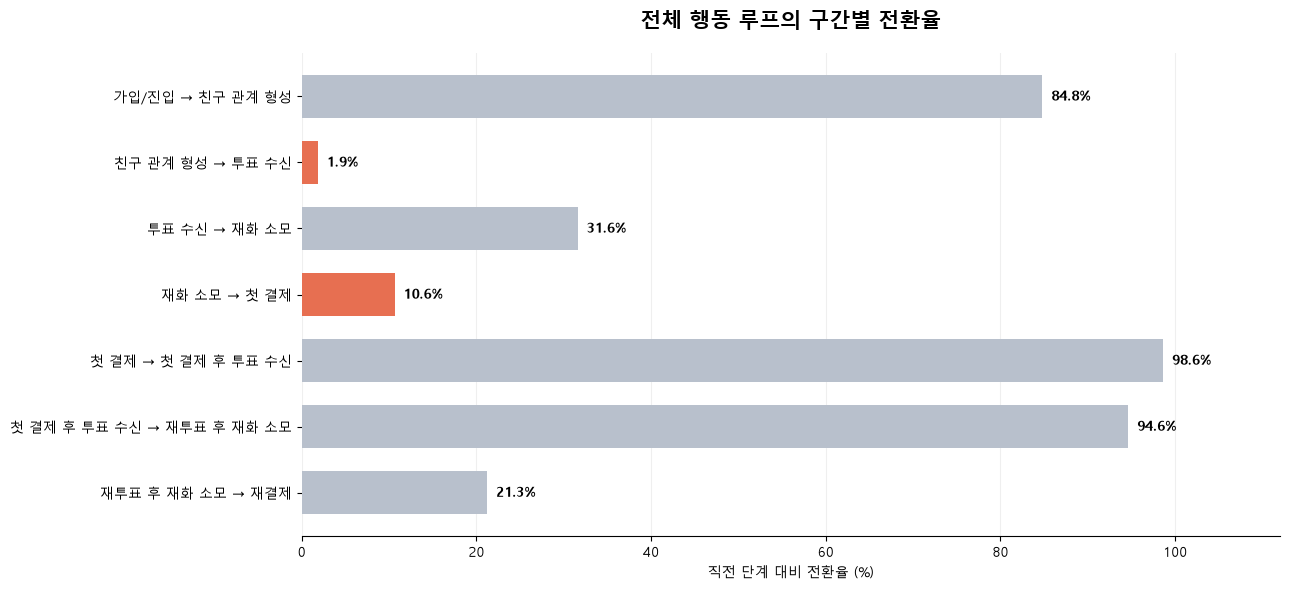

In [48]:
# 직전 단계 → 다음 단계 이름 생성
df_rate = funnel_all.iloc[1:].copy()

df_rate["구간"] = [
    f"{funnel_all.iloc[i-1]['퍼널 기준']} → {funnel_all.iloc[i]['퍼널 기준']}"
    for i in range(1, len(funnel_all))
]

df_rate["전환율(%)"] = df_rate["구간 전환율"] * 100

# 선정 구간: Step 2→3, Step 4→5
selected_idx = [2, 4]

colors = [
    "#E76F51" if i in selected_idx else "#B8C0CC"
    for i in range(1, len(funnel_all))
]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(
    df_rate["구간"],
    df_rate["전환율(%)"],
    color=colors,
    height=0.65
)

# 전환율 표시
for bar, value in zip(bars, df_rate["전환율(%)"]):
    if pd.notna(value):
        ax.text(
            value + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_title(
    "전체 행동 루프의 구간별 전환율",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("직전 단계 대비 전환율 (%)")
ax.set_xlim(0, 112)
ax.invert_yaxis()

ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 13. 전체 행동 루프의 단계별 사용자 수 변화 (3가지 유형의 그래프 비교)

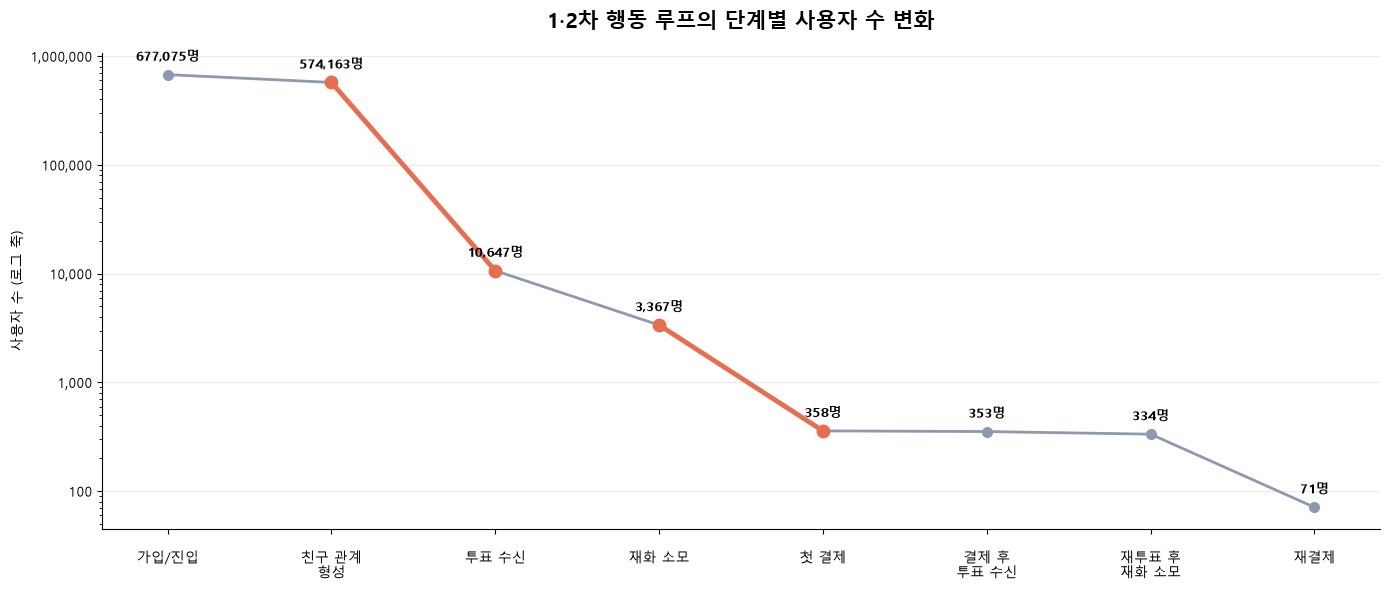

In [12]:
df_viz = funnel_all.copy()

x = np.arange(len(df_viz))
y = df_viz["사용자 수"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    x, y,
    marker="o",
    markersize=7,
    linewidth=2,
    color="#8D99AE",
    zorder=2
)

# Step 2→3, Step 4→5 강조
for start_idx in [1, 3]:
    ax.plot(
        x[start_idx:start_idx + 2],
        y[start_idx:start_idx + 2],
        marker="o",
        markersize=9,
        linewidth=3.5,
        color="#E76F51",
        zorder=3
    )

# 단계별 사용자 수 표시
for i, count in enumerate(y):
    ax.annotate(
        f"{int(count):,}명",
        (x[i], count),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# 사용자 규모 차이가 크므로 로그 축 사용
if (y > 0).all():
    ax.set_yscale("log")
else:
    ax.set_yscale("symlog", linthresh=1)

# X축 단계명 수정
step_labels = [
    "가입/진입",
    "친구 관계\n형성",
    "투표 수신",
    "재화 소모",
    "첫 결제",
    "결제 후\n투표 수신",
    "재투표 후\n재화 소모",
    "재결제"
]

ax.set_xticks(x)
ax.set_xticklabels(
    step_labels,
    rotation=0,
    ha="center",
    fontsize=10
)

ax.tick_params(axis="x", pad=12)
ax.set_xlim(-0.4, len(x) - 0.6)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda value, pos: f"{value:,.0f}"
    )
)

ax.set_title(
    "1·2차 행동 루프의 단계별 사용자 수 변화",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_ylabel("사용자 수 (로그 축)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", which="major", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

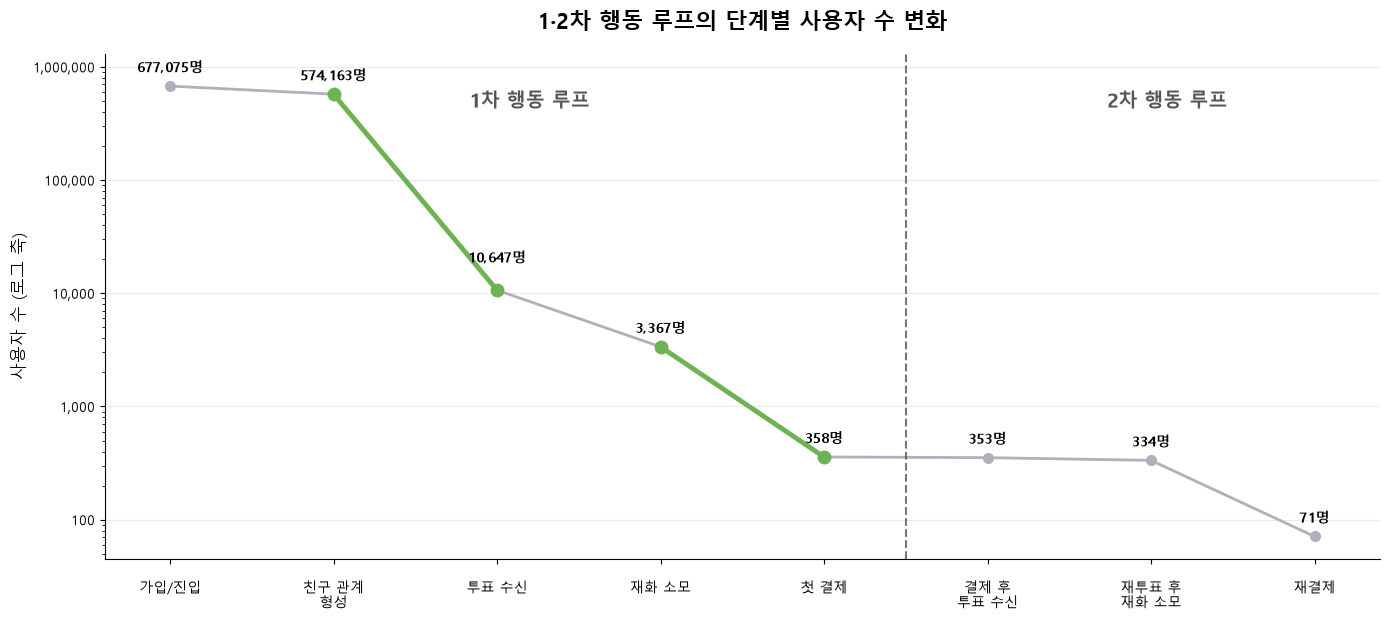

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_viz = funnel_all.copy()

x = np.arange(len(df_viz))
y = df_viz["사용자 수"].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6.3))

# 전체 사용자 수 변화
ax.plot(
    x, y,
    marker="o",
    markersize=7,
    linewidth=2,
    color="#AEB1BB",
    zorder=2
)

# 선정 구간 강조: Step 2→3, Step 4→5
for start_idx in [1, 3]:
    ax.plot(
        x[start_idx:start_idx + 2],
        y[start_idx:start_idx + 2],
        marker="o",
        markersize=9,
        linewidth=3.5,
        color="#6DB253",
        zorder=3
    )

# 1·2차 행동 루프 구분선
ax.axvline(
    x=4.5,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# 로그 축
ax.set_yscale("log")

# y축 범위 상단 여유 주기
ax.set_ylim(45, 1_300_000)

# 루프 구분 표시
ax.text(
    2.2, 500000,
    "1차 행동 루프",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="#555555"
)

ax.text(
    6.1, 500000,
    "2차 행동 루프",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color="#555555"
)

# 단계별 사용자 수 라벨 위치 개별 조정
label_offsets = [
    (0, 10),    # 가입/진입
    (0, 10),    # 친구 관계 형성
    (0, 20),    # 투표 수신 - 선과 안 겹치게 조금 더 위로
    (0, 10),    # 재화 소모
    (0, 10),    # 첫 결제
    (0, 10),    # 결제 후 투표 수신
    (0, 10),    # 재투표 후 재화 소모
    (0, 10)     # 재결제
]

for i, count in enumerate(y):
    dx, dy = label_offsets[i]
    ax.annotate(
        f"{int(count):,}명",
        (x[i], count),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

step_labels = [
    "가입/진입",
    "친구 관계\n형성",
    "투표 수신",
    "재화 소모",
    "첫 결제",
    "결제 후\n투표 수신",
    "재투표 후\n재화 소모",
    "재결제"
]

ax.set_xticks(x)

ax.set_xticklabels(
    step_labels,
    rotation=0,
    ha="center",
    fontsize=10
)

ax.tick_params(axis="x", pad=12)
ax.set_xlim(-0.4, len(x) - 0.6)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda value, pos: f"{value:,.0f}"
    )
)

ax.set_title(
    "1·2차 행동 루프의 단계별 사용자 수 변화",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_ylabel("사용자 수 (로그 축)", fontsize=12)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", which="major", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

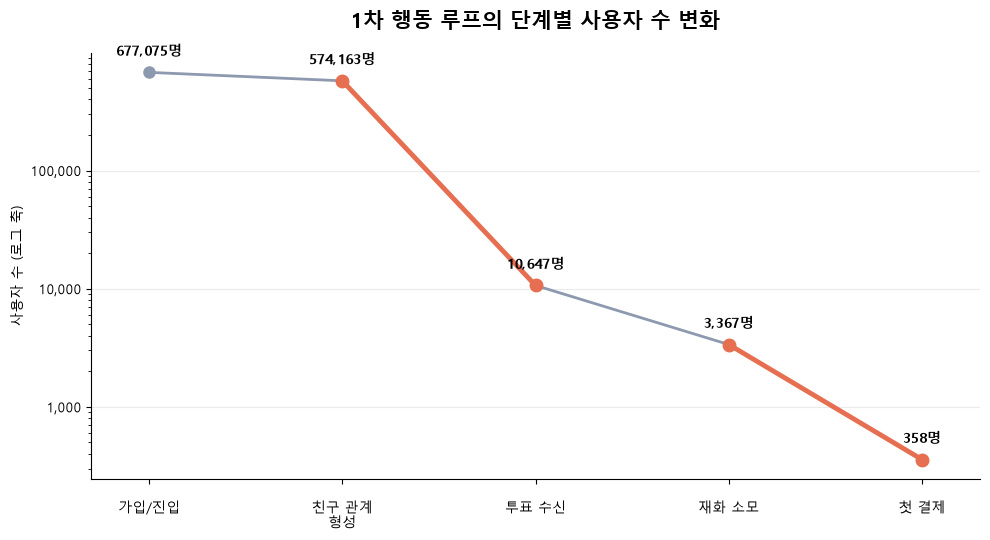

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1차 행동 루프: Step 1~5
df_loop1 = funnel_all.iloc[:5].copy()

x = np.arange(len(df_loop1))
y = df_loop1["사용자 수"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5.5))

# 전체 사용자 수 변화
ax.plot(
    x, y,
    marker="o",
    markersize=8,
    linewidth=2,
    color="#8D99AE",
    zorder=2
)

# 선정 구간 강조: Step 2→3, Step 4→5
for start_idx in [1, 3]:
    ax.plot(
        x[start_idx:start_idx + 2],
        y[start_idx:start_idx + 2],
        marker="o",
        markersize=9,
        linewidth=3.5,
        color="#E76F51",
        zorder=3
    )

# 사용자 수 표시
for i, count in enumerate(y):
    ax.annotate(
        f"{int(count):,}명",
        (x[i], count),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# 로그 축
ax.set_yscale("log")

step_labels = [
    "가입/진입",
    "친구 관계\n형성",
    "투표 수신",
    "재화 소모",
    "첫 결제"
]

ax.set_xticks(x)

ax.set_xticklabels(
    step_labels,
    rotation=0,
    ha="center",
    fontsize=10
)

ax.tick_params(axis="x", pad=12)
ax.set_xlim(-0.3, len(x) - 0.7)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda value, pos: f"{value:,.0f}"
    )
)

ax.set_title(
    "1차 행동 루프의 단계별 사용자 수 변화",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_ylabel("사용자 수 (로그 축)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", which="major", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

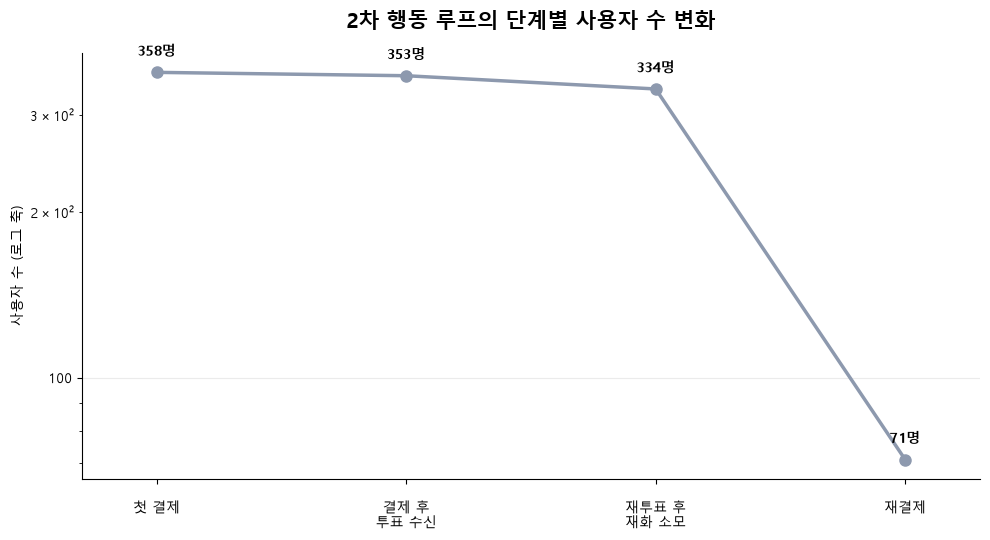

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 2차 행동 루프: 첫 결제부터 재결제까지
df_loop2 = funnel_all.iloc[4:].copy()

x = np.arange(len(df_loop2))
y = df_loop2["사용자 수"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5.5))

# 사용자 수 변화
ax.plot(
    x, y,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#8D99AE",
    zorder=2
)

# 사용자 수 표시
for i, count in enumerate(y):
    ax.annotate(
        f"{int(count):,}명",
        (x[i], count),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# 로그 축
ax.set_yscale("log")

step_labels = [
    "첫 결제",
    "결제 후\n투표 수신",
    "재투표 후\n재화 소모",
    "재결제"
]

ax.set_xticks(x)

ax.set_xticklabels(
    step_labels,
    rotation=0,
    ha="center",
    fontsize=10
)

ax.tick_params(axis="x", pad=12)
ax.set_xlim(-0.3, len(x) - 0.7)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda value, pos: f"{value:,.0f}"
    )
)

ax.set_title(
    "2차 행동 루프의 단계별 사용자 수 변화",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_ylabel("사용자 수 (로그 축)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", which="major", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 14. 선정 구간의 전환·미전환 비중 비교

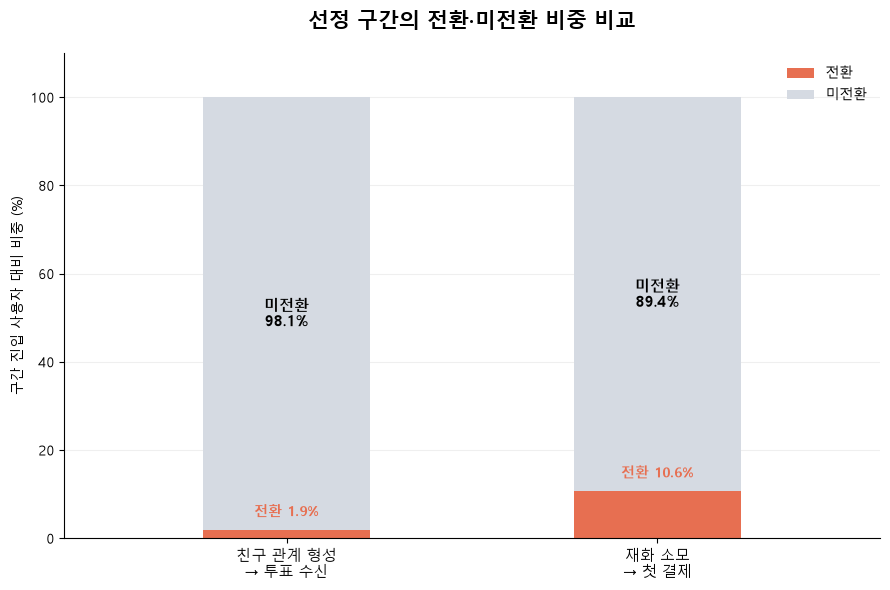

In [16]:
# Step 2→3, Step 4→5 데이터 추출
df_selected = funnel_all.iloc[[2, 4]].copy()

df_selected["전환(%)"] = (
    df_selected["구간 전환율"] * 100
)

df_selected["미전환(%)"] = (
    100 - df_selected["전환(%)"]
)

df_selected["구간명"] = [
    "친구 관계 형성\n→ 투표 수신",
    "재화 소모\n→ 첫 결제"
]

# 그래프 생성
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(df_selected))
bar_width = 0.45

# 전환 비중: 주황색 막대
ax.bar(
    x,
    df_selected["전환(%)"],
    width=bar_width,
    color="#E76F51",
    label="전환"
)

# 미전환 비중: 회색 막대
ax.bar(
    x,
    df_selected["미전환(%)"],
    bottom=df_selected["전환(%)"],
    width=bar_width,
    color="#D5DAE2",
    label="미전환"
)

# 비율 표시
for i in range(len(df_selected)):
    conversion = df_selected.iloc[i]["전환(%)"]
    non_conversion = df_selected.iloc[i]["미전환(%)"]

    # 전환율: 주황색 막대 바로 위 + 가로 중앙
    ax.annotate(
        f"전환 {conversion:.1f}%",
        xy=(x[i], conversion),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#E76F51"
    )

    # 미전환율: 회색 막대 내부 중앙
    ax.text(
        x[i],
        conversion + non_conversion / 2,
        f"미전환\n{non_conversion:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# X축 설정
ax.set_xticks(x)

ax.set_xticklabels(
    df_selected["구간명"],
    ha="center",
    fontsize=11
)

# Y축 설정
ax.set_ylim(0, 110)
ax.set_xlim(-0.6, len(x) - 0.4)

ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("구간 진입 사용자 대비 비중 (%)")

# 제목
ax.set_title(
    "선정 구간의 전환·미전환 비중 비교",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# 범례
ax.legend(
    loc="upper right",
    frameon=False
)

# 그래프 스타일
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 첫 재화 소모와 첫 결제의 발생 순서 검증 결과 시각화

#### 라이브러리 및 한글 폰트 설정

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

#### 사용자별 첫 재화 소모 및 첫 결제 시각 추출

In [18]:
first_spend = (
    df_point2
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={"created_at": "first_spend_at"})
)

first_payment = (
    df_payment2
    .groupby("user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={"created_at": "first_payment_at"})
)

# 두 행동을 모두 경험한 사용자
df_order_check = first_spend.merge(
    first_payment,
    on="user_id",
    how="inner"
)

print(f"분석 대상: {len(df_order_check):,}명")

분석 대상: 399명


In [19]:
df_order_check["first_spend_at"] = pd.to_datetime(
    df_order_check["first_spend_at"]
)

df_order_check["first_payment_at"] = pd.to_datetime(
    df_order_check["first_payment_at"]
)

spend_first = (
    df_order_check["first_spend_at"]
    < df_order_check["first_payment_at"]
).sum()

payment_first = (
    df_order_check["first_payment_at"]
    < df_order_check["first_spend_at"]
).sum()

print(f"재화 소모 먼저: {spend_first:,}명")
print(f"결제 먼저: {payment_first:,}명")
print(f"분석 대상: {len(df_order_check):,}명")

재화 소모 먼저: 375명
결제 먼저: 24명
분석 대상: 399명


#### 첫 재화 소모와 첫 결제의 발생 순서별 사용자 수 및 비율

In [20]:
# 앞에서 생성한 df_order_check 사용
df_order_check = df_order_check.copy()

# 날짜형 변환
df_order_check["first_spend_at"] = pd.to_datetime(
    df_order_check["first_spend_at"]
)

df_order_check["first_payment_at"] = pd.to_datetime(
    df_order_check["first_payment_at"]
)

# 발생 순서별 사용자 수 계산
spend_first = (
    df_order_check["first_spend_at"]
    < df_order_check["first_payment_at"]
).sum()

payment_first = (
    df_order_check["first_payment_at"]
    < df_order_check["first_spend_at"]
).sum()

# 결과 데이터프레임 생성
df_order = pd.DataFrame({
    "발생 순서": ["재화 소모 먼저", "결제 먼저"],
    "사용자 수": [spend_first, payment_first]
})

# 비율 계산
df_order["비율"] = (
    df_order["사용자 수"]
    / df_order["사용자 수"].sum()
    * 100
)

df_order_view = df_order.copy()
df_order_view["비율"] = df_order_view["비율"].map(lambda x: f"{x:.1f}%")

display(df_order_view)

,발생 순서,사용자 수,비율
0,재화 소모 먼저,375,94.0%
1,결제 먼저,24,6.0%


#### 첫 재화 소모와 첫 결제의 발생 순서

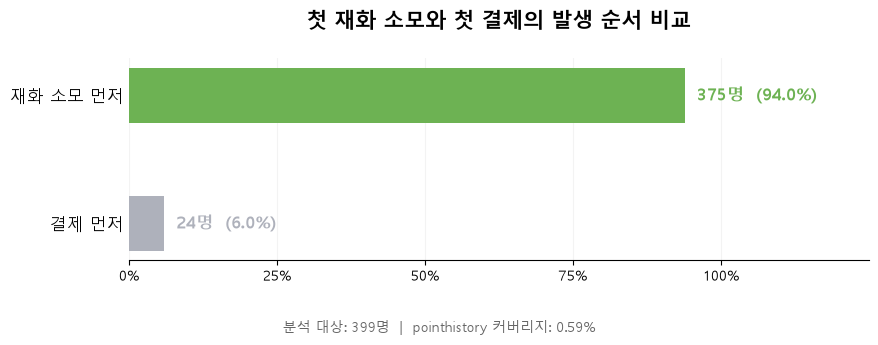

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 폰트 설정
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

# 앞에서 계산한 df_order 사용
df_plot = df_order.copy()

# 분석 대상 사용자 수
total_users = int(df_plot["사용자 수"].sum())

# pointhistory 커버리지
point_users = df_point2["user_id"].nunique()
all_user_count = df_user2["id"].nunique()

point_coverage = (
    point_users / all_user_count * 100
    if all_user_count > 0 else 0
)

# 그래프
fig, ax = plt.subplots(figsize=(10, 3.8))

y = np.arange(len(df_plot))

colors = ["#6DB253", "#AEB1BB"]

bars = ax.barh(
    y,
    df_plot["비율"],
    color=colors,
    height=0.43
)

# 막대 끝에 사용자 수와 비율 표시
for i, (bar, count, rate) in enumerate(zip(
    bars,
    df_plot["사용자 수"],
    df_plot["비율"]
)):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}명  ({rate:.1f}%)",
        ha="left",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=colors[i]
    )

# Y축
ax.set_yticks(y)
ax.set_yticklabels(
    df_plot["발생 순서"],
    fontsize=12
)

ax.invert_yaxis()
ax.tick_params(axis="y", length=0)

# X축
ax.set_xlim(0, 125)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])

# 제목
ax.set_title(
    "첫 재화 소모와 첫 결제의 발생 순서 비교",
    fontsize=15,
    fontweight="bold",
    pad=22
)

# 스타일
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
ax.set_axisbelow(True)

# 그래프 하단 분석 조건: 실제 데이터에서 계산
fig.text(
    0.5, 0.06,
    f"분석 대상: {total_users:,}명  |  "
    f"pointhistory 커버리지: {point_coverage:.2f}%",
    ha="center",
    fontsize=10,
    color="#666666"
)

plt.subplots_adjust(
    left=0.19,
    right=0.93,
    top=0.78,
    bottom=0.25
)

plt.show()